In [1]:
!pip install boto3 paramiko aiohttp

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import boto3, os, paramiko, requests, random, asyncio, aiohttp, time, hashlib

In [3]:
# Compute team seed
student_ids = sorted(["1879356","2554694"]) # your team's IDs, as strings
joined = "-".join(student_ids)
TeamSeed = int(hashlib.sha256(joined.encode()).hexdigest(), 16) % 10000
print(f'Team seed is {TeamSeed}')

Team seed is 4459


In [4]:
# Local private key pair file
key_file = r"C:\Users\XueweiLi\Desktop\TP-LOG8415E\labsuser.pem"
key_name = "vockey"

In [5]:
# constant
region_name="us-east-1"

N_small_instance = 5
small_cluster = 'cluster1'
smallInstanceType="t3.micro"
small_ImageId="ami-0fef201115eefe936"

# c7g.large is cheaper than m7g.large
N_large_instance = 4
large_cluster = 'cluster2'
largeInstanceType="c7g.large"
large_ImageId="ami-0eb45f74aa8a20238"

# create ec2 object
# boto3.client = API-oriented, more complete (specify the operation first, then pass the resource as a parameter)
# boto3.resource = object-oriented, convenient for working with a specific resource (specify the resource first, then perform an operation on that resource)
ec2_cli = boto3.client("ec2", region_name=region_name)
ec2_res = boto3.resource("ec2", region_name=region_name)
elbv2_cli = boto3.client("elbv2", region_name=region_name)

response = ec2_cli.describe_vpcs(
    Filters=[
        {
            "Name": "is-default",
            "Values": ["true"]
        }
    ]
)

VpcId = response["Vpcs"][0]["VpcId"]

In [6]:
# Find subnets in the current region so that instances can be randomly distributed across them
az_name_list = [region_name + n for n in ['a', 'b', 'c', 'd']]

response = ec2_cli.describe_subnets(
    Filters=[
        {
            "Name": "availability-zone",
            "Values": az_name_list
        }
    ]
)

subnet_dict = {}
for az_name, subnet in zip(az_name_list, response["Subnets"]):
    subnet_dict[az_name] = subnet["SubnetId"]

print(subnet_dict)

{'us-east-1a': 'subnet-079428b7924f02175', 'us-east-1b': 'subnet-03d257aecfdc22717', 'us-east-1c': 'subnet-0ddc238d067d9dce7', 'us-east-1d': 'subnet-0ef410144b236950b'}


# Cluster setup

In [7]:
# Update the OS packages and install Python3 when deploying the EC2 instance
user_data = """#!/bin/bash
sudo dnf update -y
sudo dnf install python3 python3-pip -y
"""

def create_ec2_instances(ImageId,
                         InstanceType,
                         selected_subnet,
                         SecurityGroupIds,
                         KeyName,
                        countMinMax = [1,1],
                        user_data = user_data
                        ):
    
    return ec2_res.create_instances(
        ImageId=ImageId,
        InstanceType=InstanceType,
        MinCount=countMinMax[0],
        MaxCount=countMinMax[1],
        KeyName=KeyName,
        SubnetId=subnet_dict[selected_subnet],
        SecurityGroupIds=SecurityGroupIds,
        UserData=user_data
    )

def create_ec2_tag(InstanceId, key, value):
    return ec2_cli.create_tags(
        Resources=[InstanceId],
        Tags=[
            {
                "Key": key,
                "Value": value
            }
        ]
    )

def create_security_gp(gpname, gpdescription, inboundport):
    # Security Group exists?
    response = ec2_cli.describe_security_groups(
    Filters=[
        {
            "Name": "group-name",
            "Values": [gpname]
        },
        {
            "Name": "vpc-id",
            "Values": [VpcId]
        }
    ]
    )
    
    # Get the Security Group ID if it exists
    if response["SecurityGroups"]:
        security_group_id = response["SecurityGroups"][0]["GroupId"]

        # Remove all existing inbound rules (Who is allowed to access my EC2 instance?)
        if response["SecurityGroups"][0]["IpPermissions"]:
            ec2_cli.revoke_security_group_ingress(
                GroupId=security_group_id,
                IpPermissions=response["SecurityGroups"][0]["IpPermissions"]
            )
            
    # Create a new Security Group if it does not exist.
    # https://docs.aws.amazon.com/boto3/latest/reference/services/ec2/client/create_security_group.html
    else:
        response = ec2_cli.create_security_group(
        GroupName=gpname,
        Description=gpdescription,
        VpcId=VpcId
        )
        security_group_id = response["GroupId"]
    
    # Adds the specified inbound (ingress) rules to a security group.
    # https://docs.aws.amazon.com/boto3/latest/reference/services/ec2/client/authorize_security_group_ingress.html
    for i in inboundport:
        ec2_cli.authorize_security_group_ingress(
        GroupId=security_group_id,
        IpPermissions=[
            {
                "IpProtocol": "tcp",
                "FromPort": i,
                "ToPort": i,
                "IpRanges": [
                    {
                        "CidrIp": "0.0.0.0/0" #Allow access to this port from any IPv4 address.
                    }
                ]
            }
        ]
        )
    return security_group_id

In [8]:
small_instances, large_instances = [], []

# Security group for ecs
# Port 8000: Web application traffic
# Port 22: SSH access
ec_sg_id = create_security_gp(gpname = 'TP1_sg', gpdescription = 'security group for small + large instances ecs', inboundport = [8000, 22])

# ******************************************************************** 
# cluster small
for i in range(N_small_instance):
    # Randomly select a subnet for each instance
    subnet = list(subnet_dict.keys())[random.randint(0, len(subnet_dict)-1)]

    # create an EC2 instance in that subnet
    small_instances.append(
        create_ec2_instances(ImageId=small_ImageId,
                         InstanceType=smallInstanceType,
                         selected_subnet=subnet,
                         SecurityGroupIds=[ec_sg_id],
                         KeyName=key_name)[0]
    )
# ******************************************************************** 
# cluster large
for i in range(N_large_instance):
    # Randomly select a subnet for each instance
    subnet = list(subnet_dict.keys())[random.randint(0, len(subnet_dict)-1)]

    # create an EC2 instance in that subnet
    large_instances.append(
        create_ec2_instances(ImageId=large_ImageId,
                         InstanceType=largeInstanceType,
                         selected_subnet=subnet,
                         SecurityGroupIds=[ec_sg_id],
                         KeyName=key_name)[0]
    )

# All instance IDs
all_instances = small_instances + large_instances
all_instance_ids = [instance.id for instance in all_instances]

# Wait until all instances are in the "running" state
ec2_waiter = ec2_cli.get_waiter("instance_running")

ec2_waiter.wait(
    InstanceIds=all_instance_ids
)

print("All EC2 instances are running")

All EC2 instances are running


In [9]:
# Refresh instance information from AWS
for instance in all_instances:
    instance.reload()

small_instances_ids = [i.id for i in small_instances]
print('Small Ids : ')
print(small_instances_ids)
print('----')

large_instances_ids = [i.id for i in large_instances]
print('Large Ids : ')
print(large_instances_ids)
print('----')

small_instances_ips = [i.public_ip_address for i in small_instances]
print('Small IPs : ')
print(small_instances_ips)
print('----')

large_instances_ips = [i.public_ip_address for i in large_instances]
print('Large IPs : ')
print(large_instances_ips)
print('----')

Small Ids : 
['i-08345823a1f870da8', 'i-063b319f22754b3b6', 'i-0c113cb0031317b56', 'i-0540ae5bd882de34f', 'i-05c75192626a0735b']
----
Large Ids : 
['i-0bb49eaf2d61d63a1', 'i-0190d727b2c3e37d3', 'i-0bf47b82ebc0b8c22', 'i-0aa889f1c8890b4ed']
----
Small IPs : 
['54.237.222.206', '100.31.83.157', '100.54.25.100', '3.91.37.20', '98.80.123.193']
----
Large IPs : 
['44.214.140.14', '13.221.173.120', '18.209.100.6', '54.205.87.46']
----


In [10]:
# Assign a Name tag to each EC2 instance
small_instances_name = [f'small_instance_{i}' for i in range(N_small_instance)]
for id_, val in zip(small_instances_ids, small_instances_name):
    create_ec2_tag(id_, 'Name', val)

large_instances_name = [f'large_instance_{i}' for i in range(N_large_instance)]
for id_, val in zip(large_instances_ids, large_instances_name):
    create_ec2_tag(id_, 'Name', val)

# FastAPI Deployment

#### 1. Update the OS and install Python (done when deploying the instances)

#### 2. Create the FastAPI `.py` file and deployment `.sh` script
    - .py file defines the FastAPI application
    - .sh script creates the virtual environment, installs dependencies, and starts the application

#### 3. Transfer the `.py` and `.sh` files to EC2

#### 4. Execute the deployment script

In [11]:
# Generate a FastAPI Python file for one EC2 instance
def generate_fastapi_py(
    cluster,
    instance_name,
    instance_ip,
    TeamSeed=TeamSeed
):
# Refer to the FastAPI starter template shared on Moodle
    app_code = f"""
from fastapi import FastAPI, Response
import uvicorn
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

app = FastAPI()

@app.get("/{cluster}")
def handle_request(response: Response):
    message = "{instance_name} is responding now ... "

    logger.info(message)

    response.headers["X-Team-Seed"] = "{TeamSeed}"

    return {{
        "message": message,
        "ip": "{instance_ip}",
        "TeamSeed": "{TeamSeed}"
    }}

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)
"""

    # Create the Python file locally and write the FastAPI code into it
    file_name = f"{instance_name}.py"
    with open(file_name, "w", encoding="utf-8", newline="\n") as f:
        f.write(app_code)
    return os.path.abspath(file_name)
# -------------------------------------------------------------------
# Generate a .sh provisioning file for one EC2 instance
def generate_provison_bash(instance_name):
    bash_code = f"""#!/bin/bash
cd /home/ec2-user
python3 -m venv .venv
source .venv/bin/activate
pip install fastapi "uvicorn[standard]"
nohup .venv/bin/uvicorn {instance_name}:app \
    --host 0.0.0.0 \
    --port 8000 \
    > /home/ec2-user/app.log 2>&1 < /dev/null & 
""" 
    # Create the provisioning file locally and write the Linux commands into it
    file_name = f"{instance_name}.sh"
    with open(file_name, "w", encoding="utf-8", newline="\n") as f:
        f.write(bash_code)
    return os.path.abspath(file_name)
# -------------------------------------------------------------------
# Transfer the .py and .sh files to EC2 instance & Execute the deployment script
def transfer_execute_app_sh_file(N_instance, instances_ips, app_address, bash_address, instances_name, cluster, test_app = True):
    for i in range(N_instance):
        ip = instances_ips[i]
        app_name = instances_name[i]
        local_file = app_address[i]
        local_bash_file = bash_address[i]
        remote_file = f"/home/ec2-user/{app_name}.py"
        remote_bash_file = f"/home/ec2-user/{app_name}.sh"

        print(f'{ip} : {app_name}')
    # ---------------------------------------------------------- 
        # Create an SSH client
        ssh = paramiko.SSHClient()
        # Automatically accept the EC2 host key if it is not known yet
        ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
    
        ssh.connect(
            hostname=ip,
            username="ec2-user",
            key_filename=key_file,
        )
        
        # Transfer files using SFTP 
        sftp = ssh.open_sftp()
        sftp.put(local_file, remote_file)
        sftp.put(local_bash_file, remote_bash_file)
    # ---------------------------------------------------------- 
        # Kill any process currently using port 8000
        stdin, stdout, stderr = ssh.exec_command("sudo fuser -k 8000/tcp") 
        # Make the script executable, and then run it
        stdin, stdout, stderr = ssh.exec_command(
            f"chmod +x {app_name}.sh && ./{app_name}.sh"
        )

        # Wait until the provisioning script finishes before closing the SSH connection
        # Otherwise, the deployment may be interrupted
        stdout.channel.recv_exit_status()
    
        ssh.close()
        sftp.close()
    # ---------------------------------------------------------- 
        # Test  
        if test_app : print("response:", requests.get(f"http://{ip}:8000/{cluster}").text, '\n')

In [12]:
small_app_address, small_bash_address = [], []
large_app_address, large_bash_address = [], []

# small cluster
for ins_name, ins_ip in zip(small_instances_name, small_instances_ips):
    small_app_address.append(
        generate_fastapi_py(cluster=small_cluster, instance_name=ins_name, instance_ip=ins_ip)
    )
    small_bash_address.append(
        generate_provison_bash(ins_name)
    )

transfer_execute_app_sh_file(N_small_instance, small_instances_ips, small_app_address, small_bash_address, small_instances_name, small_cluster)

# ***********************************************
# large cluster
for ins_name, ins_ip in zip(large_instances_name, large_instances_ips):
    large_app_address.append(
        generate_fastapi_py(cluster=large_cluster, instance_name=ins_name, instance_ip=ins_ip)
    )
    large_bash_address.append(
        generate_provison_bash(ins_name)
    )

transfer_execute_app_sh_file(N_large_instance, large_instances_ips, large_app_address, large_bash_address, large_instances_name, large_cluster)

54.237.222.206 : small_instance_0
response: {"message":"small_instance_0 is responding now ... ","ip":"54.237.222.206","TeamSeed":"4459"} 

100.31.83.157 : small_instance_1
response: {"message":"small_instance_1 is responding now ... ","ip":"100.31.83.157","TeamSeed":"4459"} 

100.54.25.100 : small_instance_2
response: {"message":"small_instance_2 is responding now ... ","ip":"100.54.25.100","TeamSeed":"4459"} 

3.91.37.20 : small_instance_3
response: {"message":"small_instance_3 is responding now ... ","ip":"3.91.37.20","TeamSeed":"4459"} 

98.80.123.193 : small_instance_4
response: {"message":"small_instance_4 is responding now ... ","ip":"98.80.123.193","TeamSeed":"4459"} 

44.214.140.14 : large_instance_0
response: {"message":"large_instance_0 is responding now ... ","ip":"44.214.140.14","TeamSeed":"4459"} 

13.221.173.120 : large_instance_1
response: {"message":"large_instance_1 is responding now ... ","ip":"13.221.173.120","TeamSeed":"4459"} 

18.209.100.6 : large_instance_2
resp

# AWS ALB configuration

https://digitalcloud.training/aws-elastic-load-balancing-aws-elb/  

Application Load Balancer   
↓  
Listener (HTTP, port 80)  
├── /cluster1* → Target Group 1 → EC2 instances (port 8000)  
└── /cluster2* → Target Group 2 → EC2 instances (port 8000)  
└── no matching rule → 404  

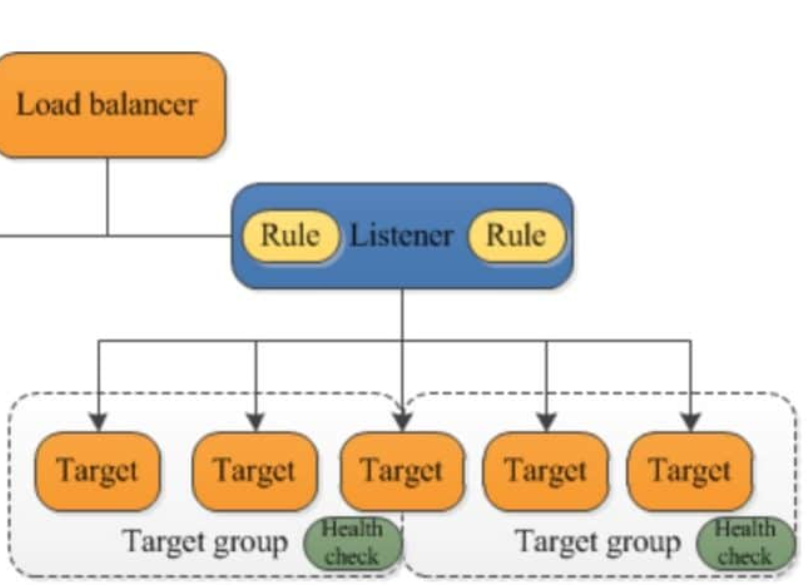

In [13]:
def create_tg_group(elbv2, cluster, VpcId=VpcId):
        
    return elbv2.create_target_group(
        Name=f"{cluster}-target-group",
        Protocol="HTTP",
        Port=8000,
        VpcId=VpcId,
        # Targets are identified by instance IDs
        TargetType="instance",

        # AWS periodically checks the instances in the cluster 
        # A successful response means the instance is healthy
        # Protocol + Target address + Port + Path
        HealthCheckProtocol="HTTP",
        HealthCheckPath=f"/{cluster}",
        HealthCheckPort="8000"
    )
    
def register_ecs_to_tg(elbv2, tg_arn, instance_ids):
    
    return elbv2.register_targets(
        TargetGroupArn=tg_arn,
        Targets=[
            {
                "Id": instance_id,
                "Port": 8000
            }
            for instance_id in instance_ids
        ]
    )

In [14]:
def create_elb_listener(elbv2_cli, SecurityGroups):
    
    # Create an application load balancer
    alb_response = elbv2_cli.create_load_balancer(        
        Name=f"alb-TP1",    
        # Attach the ALB to all available subnets
        Subnets=list(subnet_dict.values()),    
        SecurityGroups=SecurityGroups, # Requires a list
        Scheme="internet-facing",
        Type="application",
        IpAddressType="ipv4"
    )
    alb_arn = alb_response["LoadBalancers"][0]["LoadBalancerArn"]
    alb_dns = alb_response["LoadBalancers"][0]["DNSName"]

    # Create an HTTP listener on port 80
    listener_response = elbv2_cli.create_listener(
    LoadBalancerArn=alb_arn,
    Protocol="HTTP",
    Port=80,
    # Return 404 if no listener rule matches the request
    DefaultActions=[
            {
                "Type": "fixed-response",
                "FixedResponseConfig": {
                    "StatusCode": "404"
                }
            }
        ]
    )
    
    return listener_response["Listeners"][0]["ListenerArn"], alb_dns, alb_arn

# https://docs.aws.amazon.com/boto3/latest/reference/services/elbv2/client/create_rule.html#
def add_listener_rule(elbv2_cli, listener_arn, n_Priority, cluster, target_group_arn):
    # Add a rule to the ALB listener
    elbv2_cli.create_rule(
    ListenerArn=listener_arn,
    # Rule priority: each rule must have a unique priority 
    Priority=n_Priority,
    # Match requests whose URL path corresponds to the cluster
    Conditions=[
        {
            "Field": "path-pattern",
            "PathPatternConfig": {
                "Values": [
                    f"/{cluster}"
                ]
            }
        }
    ],
    # Forward matching requests to the corresponding tg
    Actions=[
        {
            "Type": "forward",
            "TargetGroupArn": target_group_arn
        }
    ]
    )
    return

In [15]:
# Create a tg for cluster 1 and register the corresponding instances with the tg
tg1 = create_tg_group(elbv2_cli, cluster=small_cluster)
tg1_arn = tg1["TargetGroups"][0]["TargetGroupArn"] 
register_ecs_to_tg(elbv2_cli, tg1_arn, small_instances_ids)

# Create a tg for cluster 2 and register the corresponding instances with the tg
tg2 = create_tg_group(elbv2_cli, cluster=large_cluster)
tg2_arn = tg2["TargetGroups"][0]["TargetGroupArn"] 
register_ecs_to_tg(elbv2_cli, tg2_arn, large_instances_ids)

{'ResponseMetadata': {'RequestId': 'd2a71f77-c709-41c7-ae8b-a8627bffb6cb',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'd2a71f77-c709-41c7-ae8b-a8627bffb6cb',
   'content-type': 'text/xml',
   'content-length': '253',
   'date': 'Sat, 26 Sep 2026 14:41:09 GMT'},
  'RetryAttempts': 0}}

In [16]:
# Create security group for ALB
alb_sg_id = create_security_gp(gpname="ALB_sg", 
                   gpdescription='Security group for ALB cluster1 + cluster2', 
                   inboundport = [80])

# Create ALB and listener
alb_listener_arn, alb_dns, alb_arn = create_elb_listener(elbv2_cli, SecurityGroups=[alb_sg_id])

# ************************************************
# Wait until the ALB is available
alb_waiter = elbv2_cli.get_waiter("load_balancer_available")

alb_waiter.wait(
    LoadBalancerArns=[alb_arn]
)

print("ALB is available")

# ************************************************
# Add a rule to listener - small cluster
add_listener_rule(elbv2_cli, alb_listener_arn, 1, small_cluster, tg1_arn)

# Add a rule to listener - large cluster
add_listener_rule(elbv2_cli, alb_listener_arn, 2, large_cluster, tg2_arn)

# ************************************************
# Wait until all registered targets become healthy
target_waiter = elbv2_cli.get_waiter("target_in_service")

target_waiter.wait(
    TargetGroupArn=tg1_arn
)

target_waiter.wait(
    TargetGroupArn=tg2_arn
)

print("All targets are healthy")

ALB is available
All targets are healthy


In [17]:
# Test: send n requests to each cluster
for _ in range(5):
    for c in [small_cluster, large_cluster]:
        response = requests.get(f"http://{alb_dns}/{c}")
        print("X-Team-Seed:", response.headers.get("X-Team-Seed"))
        print(f"Response of {c}:", response.json())

X-Team-Seed: 4459
Response of cluster1: {'message': 'small_instance_2 is responding now ... ', 'ip': '100.54.25.100', 'TeamSeed': '4459'}
X-Team-Seed: 4459
Response of cluster2: {'message': 'large_instance_1 is responding now ... ', 'ip': '13.221.173.120', 'TeamSeed': '4459'}
X-Team-Seed: 4459
Response of cluster1: {'message': 'small_instance_4 is responding now ... ', 'ip': '98.80.123.193', 'TeamSeed': '4459'}
X-Team-Seed: 4459
Response of cluster2: {'message': 'large_instance_0 is responding now ... ', 'ip': '44.214.140.14', 'TeamSeed': '4459'}
X-Team-Seed: 4459
Response of cluster1: {'message': 'small_instance_3 is responding now ... ', 'ip': '3.91.37.20', 'TeamSeed': '4459'}
X-Team-Seed: 4459
Response of cluster2: {'message': 'large_instance_3 is responding now ... ', 'ip': '54.205.87.46', 'TeamSeed': '4459'}
X-Team-Seed: 4459
Response of cluster1: {'message': 'small_instance_1 is responding now ... ', 'ip': '100.31.83.157', 'TeamSeed': '4459'}
X-Team-Seed: 4459
Response of cluster

# Terminate all

In [19]:
# ec2_cli.terminate_instances(InstanceIds = small_instances_ids+large_instances_ids)
# elbv2_cli.delete_load_balancer(LoadBalancerArn=alb_arn)

{'ResponseMetadata': {'RequestId': 'de740cdb-33ba-4626-959e-c09bd2c5cfeb',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'de740cdb-33ba-4626-959e-c09bd2c5cfeb',
   'content-type': 'text/xml',
   'content-length': '262',
   'date': 'Sat, 26 Sep 2026 14:44:25 GMT'},
  'RetryAttempts': 0}}